In [1]:
import numpy as np
import pandas as pd
import os
import glob
from helper import get_data_splits, id_key, get_model

In [2]:
# Below identifiers correspond to evaluation protocol 1, 2 and 3 respectively
# identifiers - "TouchPose_crossSession", "TouchPose_crossSubjects", "TouchPose_crossGestures"
identifier = "TouchPose_crossGestures"
data_path = "../data/eth_data/"
model_path = "../models/"
new_data = "../data/27Arish"

In [3]:
files = glob.glob(data_path+'*.pkl')
df = pd.concat([pd.read_pickle(fp) for fp in files], ignore_index=True)

In [4]:
files

['../data/eth_data/P05.pkl',
 '../data/eth_data/P06.pkl',
 '../data/eth_data/P03.pkl',
 '../data/eth_data/P01.pkl',
 '../data/eth_data/P08.pkl',
 '../data/eth_data/P04.pkl',
 '../data/eth_data/P02.pkl',
 '../data/eth_data/P07.pkl',
 '../data/eth_data/P09.pkl',
 '../data/eth_data/P10.pkl']

In [5]:
control = id_key[identifier]
df_group = df.groupby([control])[["cap_img","depth_img"]]
g_id = list(df_group.groups.keys())

In [8]:
depth_err = []
for i in range(len(g_id)):
    test_set = [g_id[i]]
    X_test_cap, Y_test_depth= get_data_splits(df_group,test_set)
    model = get_model(identifier, model_path, test_set)
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    Y_out_depth = model.predict(X_test_cap, batch_size=128)
    depth_error = np.mean(abs(Y_test_depth - Y_out_depth[:,:,:,0])) * 255
    depth_err.append(depth_error)
    print("Accuracy", g_id[i],depth_error)


Accuracy 65.0 30.41846553335639
Accuracy 66.0 24.82676614494129
Accuracy 67.0 21.052759408842057
Accuracy 68.0 23.050934089590612


KeyboardInterrupt: 

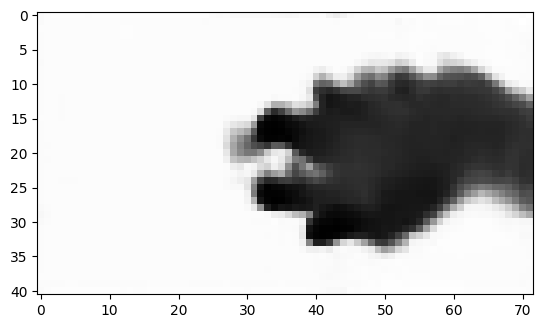

In [9]:
import matplotlib.pyplot as plt
plt.imshow(Y_out_depth[-1], cmap='gray')

In [10]:
print(identifier)
print("\t Depth Error",np.mean(depth_err),"SD",np.std(depth_err))

TouchPose_crossGestures
	 Depth Error 24.930618678882585 SD 7.062984031718188
